In [1]:
%matplotlib inline
import cv2
import numpy as np
from matplotlib import pyplot as plt

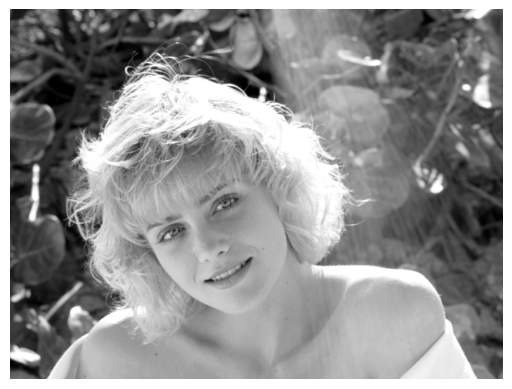

In [2]:
# Carregar a imagem em modo grayscale
imagem = cv2.imread('images/pgm_bin/marcie.pgm', cv2.IMREAD_GRAYSCALE)

# Exibindo imagem
plt.imshow(imagem, cmap='gray')
plt.axis('off') 
plt.show()

# Função de predição e sua inversa

In [3]:
def previous(x, y, img):
    if (x == 0):
        return img[y, x]
    return  img[y, x] - img[y, x-1]

def previous_inv(x, y, recons, residual):
    if (x==0):
        return residual[y,x]
    return recons[y, x-1] + residual[y, x]

## Aplicação da função preditora

In [4]:
def prediction_comp(func, img):
    size = img.shape
    residual = np.zeros(size, int)
    img = img.astype(int)
    
    for y in range(0, size[0]):
        for x in range(0, size[1]):
            # pred = func(x, y, img)

            # residual[y, x] = img[y, x] - pred
            residual[y, x] = func(x, y, img)

    return residual

In [5]:
result = prediction_comp(previous, imagem)
print(result)
print(np.max(result), np.min(result))

[[146 -12 -18 ...   4   3   3]
 [146 -13 -19 ...   2   3   3]
 [141 -11 -16 ...   2   3   3]
 ...
 [149  -1   0 ...   4   1   0]
 [150   0   0 ...   3   2  -2]
 [151  -1   3 ...   3   0   0]]
243 -88


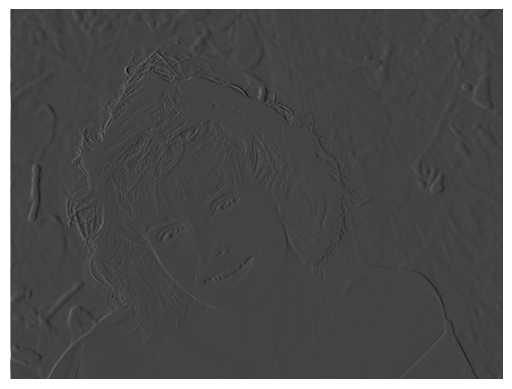

In [6]:
plt.imshow(result, cmap='gray')
plt.axis('off') 
plt.show()

# Diferença de entropia da Imagem Original vs Imagem de Resíduos

In [7]:
# image entropy
def calcEntropy(img):
    hist = cv2.calcHist([img],[0],None,[256],[0,256])
    hist = hist.ravel()/hist.sum()
    logs = np.log2(hist+0.00001)
    entropy = -1 * (hist*logs).sum()

    return entropy

def calcEntropyError(img):
    hist = cv2.calcHist([img],[0],None,[512],[0,512])
    hist = hist.ravel()/hist.sum()
    logs = np.log2(hist+0.00001)
    entropy = -1 * (hist*logs).sum()

    return entropy

In [8]:
print("Entropia da imagem original:", calcEntropy(imagem))

min_val = np.min(result)
shifted = result - min_val

print("Entropia da imagem de resíduos", calcEntropy(shifted.astype(np.uint8)))

Entropia da imagem original: 7.1393776
Entropia da imagem de resíduos 4.018912


# Aplicação da Inversa da Predição

In [9]:
def prediction_decomp(func_inv, residual):
    size = residual.shape
    reconstructed = np.zeros(size, int)
    residual = residual.astype(int)
    
    for y in range(0, size[0]):
        for x in range(0, size[1]):
            reconstructed[y, x] = func_inv(x, y, reconstructed, residual)

    return reconstructed

In [10]:
rebuilt = prediction_decomp(previous_inv, result).astype(np.uint8)

print(np.min(rebuilt), np.max(rebuilt))

80 255


# Imagem reconstruída

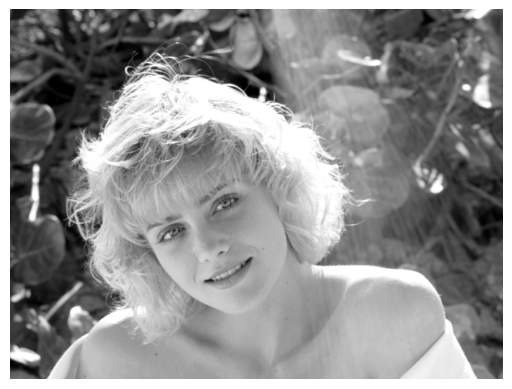

In [11]:
plt.imshow(rebuilt, cmap='gray')
plt.axis('off') 
plt.show()

In [12]:
# Root Mean Square Error
def rmse_metric(img1, img2):
    return np.sqrt(np.mean((img1.astype("float") - img2.astype("float")) ** 2))

rmse = rmse_metric(imagem, rebuilt)
print(f"Erro da reconstrução: {rmse}")

Erro da reconstrução: 0.0


In [13]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import pickle
import os
import heapq
from collections import Counter

In [14]:
class NoHuffman:
    def __init__(self, valor=None, freq=0, esq=None, dir=None):
        self.valor = valor
        self.freq = freq
        self.esq = esq
        self.dir = dir
    
    def __lt__(self, outro):  # Necessário para usar o heapq
        return self.freq < outro.freq

def construir_arb_huffman(frequencias):
    # Cria a heap com os nós folha
    heap = [NoHuffman(valor, freq) for valor, freq in frequencias.items()]
    heapq.heapify(heap)

    # Construa a árvore
    while len(heap) > 1:
        no1 = heapq.heappop(heap)
        no2 = heapq.heappop(heap)
        no_novo = NoHuffman(freq=no1.freq + no2.freq, esq=no1, dir=no2)
        heapq.heappush(heap, no_novo)

    return heap[0]  # Retorna a raiz da árvore

def gerar_codigos_huffman(raiz, prefixo="", codigos={}):
    if raiz is None:
        return
    if raiz.valor is not None:
        codigos[raiz.valor] = prefixo
    gerar_codigos_huffman(raiz.esq, prefixo + "0", codigos)
    gerar_codigos_huffman(raiz.dir, prefixo + "1", codigos)
    return codigos

# Função para aplicar a quantização e codificação de Huffman
def huffman_encode(quant_coefs):
    # Flatten a matriz para tratar os coeficientes DCT quantizados
    quant_flat = quant_coefs.flatten()
    
    # Contar a frequência dos coeficientes
    frequencias = Counter(quant_flat)

    # Construir a árvore de Huffman
    raiz = construir_arb_huffman(frequencias)
    
    # Gerar os códigos Huffman
    codigos_huffman = gerar_codigos_huffman(raiz)
    
    # Codificar a imagem (gerar a sequência binária)
    dados_codificados = ''.join([codigos_huffman[p] for p in quant_flat])
    
    return codigos_huffman, dados_codificados

def huffman_decode(dados_comprimidos):
    # Recupera os dados comprimidos e o dicionário de códigos Huffman
    dados_codificados = dados_comprimidos['dados_codificados']
    codigos_huffman = dados_comprimidos['codigos_huffman']
    
    # Inverter o dicionário de códigos Huffman para mapear os prefixos para os valores
    codigos_invertidos = {v: k for k, v in codigos_huffman.items()}
    
    # Variáveis para armazenar os coeficientes quantizados
    quant_coefs_rec = []
    i = 0  # Posição no stream de dados codificados
    
    # Descodificar os dados codificados
    while i < len(dados_codificados):
        # Tenta encontrar o código correspondente no stream de dados
        for tamanho in range(1, len(dados_codificados) - i + 1):
            prefixo = dados_codificados[i:i + tamanho]
            if prefixo in codigos_invertidos:
                # Adiciona o valor correspondente à lista de coeficientes
                quant_coefs_rec.append(codigos_invertidos[prefixo])
                i += tamanho  # Avança a posição no stream
                break
    
    # Converter a lista de coeficientes de volta para a forma matricial
    shape = dados_comprimidos['shape']
    quant_coefs_rec = np.array(quant_coefs_rec).reshape(shape)
    
    return quant_coefs_rec

import numpy as np

def huffman_decode_dft(dados_comprimidos):
    def decode(dados_codificados, codigos_huffman, shape):
        # Inverter o dicionário de códigos Huffman
        codigos_invertidos = {v: k for k, v in codigos_huffman.items()}
        
        # Lista para armazenar os coeficientes
        quant_coefs_rec = []
        i = 0  # Índice no stream de bits
        
        # Decodificação bit a bit
        while i < len(dados_codificados):
            for tamanho in range(1, len(dados_codificados) - i + 1):
                prefixo = dados_codificados[i:i + tamanho]
                if prefixo in codigos_invertidos:
                    quant_coefs_rec.append(codigos_invertidos[prefixo])
                    i += tamanho
                    break
                    
        return np.array(quant_coefs_rec).reshape(shape)
    
    # Decodificar magnitude
    magnitude = decode(
        dados_comprimidos['dados_codificados_mag'],
        dados_comprimidos['codigos_huffman_mag'],
        dados_comprimidos['shape_mag']
    )
    print("OI")
    
    # Decodificar fase
    fase = decode(
        dados_comprimidos['dados_codificados_phase'],
        dados_comprimidos['codigos_huffman_phase'],
        dados_comprimidos['shape_phase']
    )
    
    return magnitude, fase


In [15]:
huff = huffman_encode(result)

In [16]:
import sys
from bitarray import bitarray
sys.getsizeof(huff[0])

9304

In [17]:
menor = (huff[0], bitarray(huff[1]).tobytes(), len(huff[1]))
retorno = (menor[0], bitarray(menor[1]).to01()[:menor[2]])

In [18]:
print(len(retorno[1]), len(huff[1]))

1243684 1243684


In [19]:
retorno[1] == huff[1]

True

In [20]:
from bitarray import bitarray

In [21]:
# Função que realiza a transformada DCT
def dct_transform(img, step=8):

    size = img.shape                    # Shape da imagem
    DCT = np.zeros(size, dtype=float)   # Cria uma matriz para armazenar os coeficientes DCT

    for y in range(0, size[0], step):       # Percorre linhas de 8 em 8
        for x in range(0, size[1], step):   # Percorre colunas de 8 em 8
            
            dct = cv2.dct(img[y:y+step, x:x+step])   # Aplica DCT no bloco 8x8

            DCT[y:y+step, x:x+step] = dct     # Salva o bloco DCT

    return DCT

# Função que realiza a inversa da DCT (IDCT)
def idct_transform(dct_coefs, step=8):

    size = dct_coefs.shape
    IDCT = np.zeros(size, dtype=float)  # Cria uma matriz para armazenar a imagem reconstruída

    for y in range(0, size[0], step):       # Percorre linhas de 8 em 8
        for x in range(0, size[1], step):   # Percorre colunas de 8 em 8
            
            idct = cv2.idct(dct_coefs[y:y+step, x:x+step]) # Aplica IDCT 2D no bloco 8x8

            IDCT[y:y+step, x:x+step] = idct   # Salva o bloco reconstruído
    
    IDCT = IDCT + 128 # Desfaz o deslocamento de 128

    return IDCT

In [22]:
def quantizacao_DCT(DCT, QM, step=8):
    
    np.set_printoptions(precision=3)
    np.set_printoptions(suppress=True)
    
    size = DCT.shape
    quant_coefs = np.zeros(size, dtype=float) # Matriz para armazenar os coeficientes quantizados
    dc_array = []                             # Array para armazenar os coeficientes DC originais
    
    for y in range(0,size[0],step):
        for x in range(0,size[1],step):

            dct = DCT[y:y+step, x:x+step]

            DC = dct[0,0]            # Adquire o coeficiente DC
            dct = np.divide(dct, QM) # Divive a DCT pela matriz de quantização
            dct = dct.round()        # Arredondamento da matriz quantizada

            quant_coefs[y:y+step, x:x+step] = dct # Salva o bloco quantizado
            dc_array.append(DC)
    
    return quant_coefs, dc_array

def desquantization_DCT(quant_coefs, dc_array, QM, useDC=True, step=8):

    np.set_printoptions(precision=3)
    np.set_printoptions(suppress=True)
    
    size = quant_coefs.shape
    original_coefs = np.zeros(size, dtype=float)

    for y in range(0,size[0],step):
        for x in range(0,size[1],step):
            # Multiplica a matriz quantizada pela matriz de quantização
            dct = np.multiply(quant_coefs[y:y+step, x:x+step], QM)

            if (useDC == True):
                dct[0,0] = dc_array[0]  # Recupera o coeficiente DC original
                dc_array = dc_array[1:] # Retira o primeiro elemento do array
        
            original_coefs[y:y+step, x:x+step] = dct
    
    return original_coefs

In [23]:
 # Converte uma matriz 8x8 em uma lista usando o percurso zigue-zague  
def zigzag(block):  
    z = np.empty(64, dtype=block.dtype)
    index = -1
    for i in range(0, 15):
        bound = 0 if i < 8 else i - 7
        for j in range(bound, i - bound + 1):
            if i % 2 == 0:
                x, y = j, i - j
            else:
                x, y = i - j, j
            if x < 8 and y < 8:
                index += 1
                z[index] = block[x][y]
    return z

# Converte uma lista de 64 elementos em uma matriz 8x8 usando percurso zigue-zague inverso
def inverse_zigzag(array):
    block = np.empty((8, 8), dtype=array.dtype)
    index = -1
    for i in range(0, 15):
        bound = 0 if i < 8 else i - 7
        for j in range(bound, i - bound + 1):
            if i % 2 == 0:
                x, y = j, i - j
            else:
                x, y = i - j, j
            if x < 8 and y < 8:
                index += 1
                block[x][y] = array[index]
    return block

In [24]:
def dct_jpeg_compression(img, file_name, step=8):
    
    img = img.astype(float)             
    img = img - 128                     # Centraliza os valores da imagem em torno de 0

    # Matriz de Quantização
    QM = np.matrix([[16, 11, 10, 16, 24, 40, 51, 61], 
                    [12, 12, 14, 19, 26, 58, 60, 55],
                    [14, 13, 16, 24, 40, 57, 69, 56],
                    [14, 17, 22, 29, 51, 87, 80, 62],
                    [18, 22, 37, 56, 68, 109, 103, 77],
                    [24, 35, 55, 64, 81, 104, 113, 92],
                    [49, 64, 78, 87, 103, 121, 120, 101],
                    [72, 92, 95, 98, 112, 100, 103, 99]])

    # 1. Realiza Transformada DCT
    DCT = dct_transform(img)
    
    # 2. Quantização
    quant_coefs, dc_array = quantizacao_DCT(DCT, QM)
    
    # 3. Oredenação Zigue-Zague (Ainda tem que implementar)
    zigzagged_blocks = np.empty_like(quant_coefs)
    for i in range(0, quant_coefs.shape[0], 8):
        for j in range(0, quant_coefs.shape[1], 8):
            block = quant_coefs[i:i+8, j:j+8]
            zigzagged_blocks[i:i+8, j:j+8] = zigzag(block).reshape((8, 8)) 
    
    # 4. Codificação Huffman (Codificação por Entropia)
    codigos_huffman, dados_codificados = huffman_encode(zigzagged_blocks)

    # Salvando dados comprimidos:
    dados_comprimidos = {
        'dados_codificados': dados_codificados,
        'codigos_huffman': codigos_huffman,
        'shape': quant_coefs.shape,
        'dc_array': dc_array
    }
    
    path = os.path.join('images/compressed', file_name)
    dump(dados_comprimidos, path)

    # Desfaz o deslocamento de 128 da imagem
    img = img + 128


def dct_jpeg_descompression(img_path, step=8):

    # Matriz de Quantização
    QM = np.matrix([[16, 11, 10, 16, 24, 40, 51, 61], 
                    [12, 12, 14, 19, 26, 58, 60, 55],
                    [14, 13, 16, 24, 40, 57, 69, 56],
                    [14, 17, 22, 29, 51, 87, 80, 62],
                    [18, 22, 37, 56, 68, 109, 103, 77],
                    [24, 35, 55, 64, 81, 104, 113, 92],
                    [49, 64, 78, 87, 103, 121, 120, 101],
                    [72, 92, 95, 98, 112, 100, 103, 99]])

    dados_comprimidos = load(img_path)

    # Coeficientes quantizados e dc_array recuperados
    zigzagged_blocks = huffman_decode(dados_comprimidos)
    dc_array = dados_comprimidos['dc_array']
    shape = dados_comprimidos['shape']

    # Reverter Zigue Zague
    quant_coefs_rec = np.zeros(shape)
    for i in range(0, shape[0], 8):
        for j in range(0, shape[1], 8):
            zigzag_seq = zigzagged_blocks[i:i+8, j:j+8].flatten()
            block = inverse_zigzag(zigzag_seq)
            quant_coefs_rec[i:i+8, j:j+8] = block
    # Desquantização
    original_coefs = desquantization_DCT(quant_coefs_rec, dc_array, QM)

    # Realiza a Transformada Inversa (IDCT)
    img_rec = idct_transform(original_coefs, step)

    return img_rec

In [29]:
def dump(dados, path):
    bin_string = dados['dados_codificados']
    data_bytes = bitarray(bin_string).tobytes()

    dados['dados_codificados'] = (data_bytes, len(bin_string))
    
    with open(path, 'wb') as f:
        pickle.dump(dados, f)

    print(dados.keys())
    print(f"Dados comprimidos salvos em {path}")

def load(path):
    with open(path, 'rb') as f:
        dados_comprimidos = pickle.load(f)
    
    codigos = dados_comprimidos['dados_codificados']
    bin_string = bitarray(codigos[0]).to01()[:codigos[1]]

    dados_comprimidos['dados_codificados'] = bin_string

    return dados_comprimidos
    

In [26]:
# Compressão
img = imagem.copy()
img = img.astype(float)

file_name = 'marcie_comprimida_jpeg_dct.huff'
dct_jpeg_compression(img, file_name)

dict_keys(['dados_codificados', 'codigos_huffman', 'shape', 'dc_array'])
Dados comprimidos salvos em images/compressed/marcie_comprimida_jpeg_dct.huff


In [41]:
with open("images/compressed/marcie_comprimida_jpeg_dct.huff", 'rb') as f:    
    codes_size = pickle.load(f)['dados_codificados'][1]

# Taxa de compressão
original_size = os.path.getsize("images/pgm_bin/marcie.pgm") 
compressed_size = os.path.getsize("images/compressed/marcie_comprimida_jpeg_dct.huff")
taxa_de_compressao = original_size / compressed_size

print(original_size, compressed_size, codes_size)
print(f"Taxa de compressão (com overhead) = {taxa_de_compressao}")
print(f"Taca de compressão (sem overhead) = ", original_size / codes_size)

307215 168066 425604
Taxa de compressão (com overhead) = 1.8279425939809362
Taca de compressão (sem overhead) =  0.7218329714946288


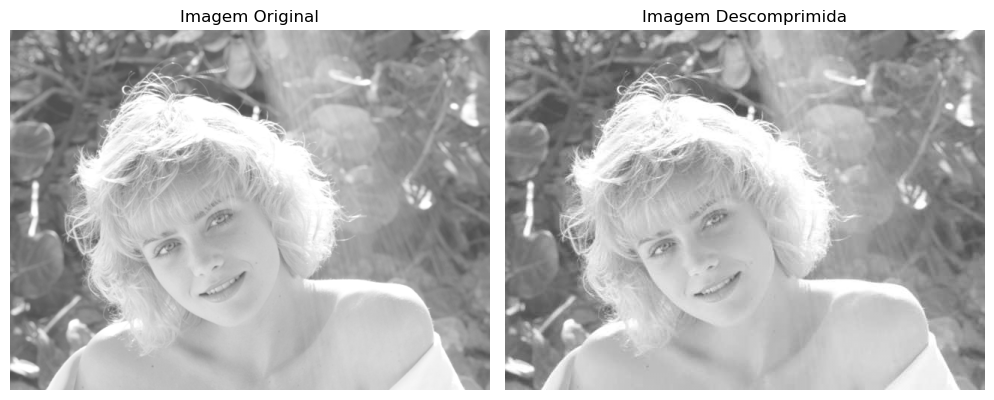

In [30]:
# Descompressão
img_path = 'images/compressed/marcie_comprimida_jpeg_dct.huff'
img_rec = dct_jpeg_descompression(img_path)

# Visualização
# Imagem Original
plt.figure(figsize=(15,5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem Original')
plt.axis('off')

# Imagem Descomprimida
plt.subplot(1, 3, 2)
plt.imshow(img_rec, cmap='gray', vmin=0, vmax=255)
plt.title('Imagem Descomprimida')
plt.axis('off')

plt.tight_layout()
plt.show()